In [1]:
import sys
import os
sys.path.append('/root/capsule/code/beh_ephys_analysis')
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import pandas as pd
from pynwb import NWBFile, TimeSeries, NWBHDF5IO
import json
import seaborn as sns
from PyPDF2 import PdfMerger
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import re
from utils.beh_functions import session_dirs, parseSessionID, load_model_dv, makeSessionDF, get_session_tbl, get_unit_tbl, get_history_from_nwb, plot_session_glm
from utils.ephys_functions import*
from utils.ccf_utils import ccf_pts_convert_to_mm
from utils.capsule_migration import capsule_directories
import pickle
import scipy.stats as stats
import spikeinterface as si
import shutil
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import r2_score
from matplotlib import cm
import matplotlib.colors as mcolors
from joblib import Parallel, delayed
from utils.combine_tools import apply_qc
capsule_dirs = capsule_directories()
%matplotlib inline


In [2]:
beh_combined_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/combined_session_tbl/combined_beh_sessions.pkl'
with open(beh_combined_file, 'rb') as f:
    beh_combined = pickle.load(f)

In [3]:
# regression model, use past rewards/no reward,  to predict future go/no-go
def hit_glm(session):
    session_tbl = get_session_tbl(session)

    t_Max = 3
    t_Max_hist = 0

    hit = session_tbl['animal_response'].values != 2
    rewards = (session_tbl['rewarded_historyL'].values == 1) | (session_tbl['rewarded_historyR'].values == 1)
    rewards[~hit] = np.nan  # only consider rewards when there is a hit
    choice = session_tbl['animal_response'].values
    pre_choice = np.full(len(choice), np.nan)
    pre_choice[1:] = choice[:-1]
    for i in range(1, len(choice)):
        if pre_choice[i] == 2:  # no-go
            last_choice = np.where(choice[:i] != 2)[0][-1] if np.any(choice[:i] != 2) else 0
            pre_choice[i] = choice[last_choice] if last_choice > 0 else np.nan

    # for each pre_choice == 2, get the lastest choice that is not 2


    hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
    for i in range(t_Max_hist):
        hit_mtx[i, i+1:] = hit[:(len(hit)-(i+1))]

    rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
    for i in range(t_Max):
        rwd_mtx[i, i+1:] = rewards[:(len(hit)-(i+1))]
    col_list = [f'rwd_{i+1}' for i in range(t_Max)]
    pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
    col_list.extend(pre_hist_list)
    matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
    reg_df = pd.DataFrame(matrix.T, columns=col_list)
    reg_df['hit'] = hit
    # reg_df['pre_choice'] = pre_choice
    # use statsmodels to fit a GLM
    X = reg_df.drop(columns=['hit']).values
    y = reg_df['hit'].values
    X = sm.add_constant(X)  # add intercept term
    # nan mask to filter nan mask
    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]
    model = sm.Logit(y, X)
    result = model.fit()
    # print(result.summary())

    rwd_coeffs = result.params[1:t_Max+1]
    hit_coeffs = result.params[t_Max+1:-1]
    # pre_choice_coeff = result.params[-1]

    # # plot coefficients
    # plt.figure(figsize=(10, 6))
    # plt.bar(range(t_Max), rwd_coeffs, label='Reward Coefficients', alpha=0.7)
    # plt.bar(range(t_Max, t_Max + t_Max_hist + 1), hit_coeffs, label='Hit Coefficients', alpha=0.7)
    # plt.bar(range(t_Max + t_Max_hist + 1, t_Max + t_Max_hist+2), pre_choice_coeff, label='Hit Coefficients', alpha=0.7)
    # plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # plt.xlabel('Time Lag')
    # plt.ylabel('Coefficient Value')
    # plt.title('GLM Coefficients for Reward and Hit History')
    return {'rwd_coeffs': rwd_coeffs,
            'hit_coeffs': hit_coeffs,
            # 'pre_choice_coeff': pre_choice_coeff,
            'session_id': session}



In [4]:
# regression model, use past rewards/no reward,  to predict future go/no-go
def hit_glm_ani(ani, t_Max = 3, t_Max_hist = 0):

    session_list_file = f'{capsule_dirs["manuscript_fig_prep_dir"]}/combined_session_tbl/combined_beh_sessions.pkl'
    with open(session_list_file, 'rb') as f:
        combined_session_tbl = pickle.load(f)
    session_list = combined_session_tbl[combined_session_tbl['ani_id'] == ani]['session_id'].values
    combined_reg_df = pd.DataFrame()
    for session in session_list:
        session_tbl = get_session_tbl(session)

        hit = session_tbl['animal_response'].values != 2
        rewards = (session_tbl['rewarded_historyL'].values == 1) | (session_tbl['rewarded_historyR'].values == 1)
        # rewards[~hit] = np.nan  # only consider rewards when there is a hit
        choice = session_tbl['animal_response'].values
        pre_choice = np.full(len(choice), np.nan)
        pre_choice[1:] = choice[:-1]
        for i in range(1, len(choice)):
            if pre_choice[i] == 2:  # no-go
                last_choice = np.where(choice[:i] != 2)[0][-1] if np.any(choice[:i] != 2) else 0
                pre_choice[i] = choice[last_choice] if last_choice > 0 else np.nan

        hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
        for i in range(t_Max_hist):
            hit_mtx[i, i+1:] = hit[:(len(hit)-(i+1))]

        rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
        for i in range(t_Max):
            rwd_mtx[i, i+1:] = rewards[:(len(hit)-(i+1))]
        # create a DataFrame for regression
        col_list = [f'rwd_{i+1}' for i in range(t_Max)]
        pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
        col_list.extend(pre_hist_list)
        matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
        reg_df = pd.DataFrame(matrix.T, columns=col_list)
        reg_df['hit'] = hit
        # reg_df['pre_choice'] = pre_choice
        # use statsmodels to fit a GLM
        # nan_df = df.DataFrame(np.full((len(reg_df), len(reg_df.columns)), np.nan), columns=reg_df.columns)
        combined_reg_df = pd.concat([combined_reg_df, reg_df], ignore_index=True)

    X = combined_reg_df.drop(columns=['hit']).values
    y = combined_reg_df['hit'].values
    X = sm.add_constant(X)  # add intercept term
    # nan mask to filter nan mask
    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]
    model = sm.Logit(y, X)
    result = model.fit()
    # print(result.summary())

    rwd_coeffs = result.params[1:t_Max+1]
    hit_coeffs = result.params[t_Max+1:-1]
    # pre_choice_coeff = result.params[-1]
    rwd_CI = result.conf_int()[1:t_Max+1]
    hit_CI = result.conf_int()[t_Max+1:-1]

    # # plot coefficients
    # plt.figure(figsize=(10, 6))
    # plt.bar(range(t_Max), rwd_coeffs, label='Reward Coefficients', alpha=0.7)
    # plt.bar(range(t_Max, t_Max + t_Max_hist + 1), hit_coeffs, label='Hit Coefficients', alpha=0.7)
    # plt.bar(range(t_Max + t_Max_hist + 1, t_Max + t_Max_hist+2), pre_choice_coeff, label='Hit Coefficients', alpha=0.7)
    # plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
    # plt.xlabel('Time Lag')
    # plt.ylabel('Coefficient Value')
    # plt.title('GLM Coefficients for Reward and Hit History')
    return {'rwd_coeffs': rwd_coeffs,
            'hit_coeffs': hit_coeffs,
            'rwd_CI': rwd_CI,
            'hit_CI': hit_CI,
            # 'pre_choice_coeff': pre_choice_coeff,
            'ani_id': ani}



In [5]:
ani_ids = beh_combined['ani_id'].unique()
t_Max = 10
all_results = []
for ani in ani_ids:
    print(f'Processing animal {ani}')
    try:
        result = hit_glm_ani(ani, t_Max=t_Max, t_Max_hist=0)
        all_results.append(result)
        print(result)
    except:
        print(f'Error processing animal {ani}')
        continue

Processing animal 808655
Optimization terminated successfully.
         Current function value: 0.087769
         Iterations 9
{'rwd_coeffs': array([0.85198323, 0.81503742, 0.49922337, 0.37289723, 0.09585583,
       1.09537392, 0.46682753, 1.19235004, 0.53332557, 0.02090822]), 'hit_coeffs': array([], dtype=float64), 'rwd_CI': array([[-0.25485036,  1.95881682],
       [-0.29466653,  1.92474138],
       [-0.5269335 ,  1.52538025],
       [-0.66001066,  1.40580511],
       [-0.87706039,  1.06877205],
       [-0.1549425 ,  2.34569033],
       [-0.56617778,  1.49983283],
       [-0.05619068,  2.44089077],
       [-0.49482325,  1.56147438],
       [-0.90544015,  0.9472566 ]]), 'hit_CI': array([], shape=(0, 2), dtype=float64), 'ani_id': '808655'}
Processing animal 808650
Optimization terminated successfully.
         Current function value: 0.072931
         Iterations 9
{'rwd_coeffs': array([ 0.0346357 , -0.35442454, -0.01268572, -0.16600605, -0.35156583,
        0.04322561, -0.24044403,  0.

/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Error processing animal 835451
Processing animal 838332
Optimization terminated successfully.
         Current function value: 0.151054
         Iterations 11
{'rwd_coeffs': array([2.26836197, 3.37776933, 2.04446522, 1.71133864, 1.49685662,
       1.8833114 , 1.61432449, 1.0644035 , 1.56133511, 1.04900881]), 'hit_coeffs': array([], dtype=float64), 'rwd_CI': array([[1.07594781, 3.46077613],
       [1.38249295, 5.37304571],
       [0.84521154, 3.24371889],
       [0.65214038, 2.77053691],
       [0.53139698, 2.46231626],
       [0.82823737, 2.93838543],
       [0.65231798, 2.576331  ],
       [0.26343935, 1.86536765],
       [0.67595504, 2.44671518],
       [0.28791873, 1.8100989 ]]), 'hit_CI': array([], shape=(0, 2), dtype=float64), 'ani_id': '838332'}
Processing animal 841596
Optimization terminated successfully.
         Current function value: 0.230213
         Iterations 8
{'rwd_coeffs': array([ 1.30015927,  0.94563437,  0

/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


         Current function value: 0.020002
         Iterations: 35
{'rwd_coeffs': array([ 0.19219227,  0.09741578, 24.08649428,  1.17690303, -0.69742794,
        0.19276797,  0.21087186,  0.20024768,  0.38911039, -0.34198241]), 'hit_coeffs': array([], dtype=float64), 'rwd_CI': array([[-1.56563755e+00,  1.95002209e+00],
       [-1.66695313e+00,  1.86178469e+00],
       [-1.54813612e+05,  1.54861785e+05],
       [-1.03846131e+00,  3.39226738e+00],
       [-2.37930752e+00,  9.84451649e-01],
       [-1.58098662e+00,  1.96652256e+00],
       [-1.55597896e+00,  1.97772269e+00],
       [-1.58723582e+00,  1.98773117e+00],
       [-1.39996392e+00,  2.17818470e+00],
       [-2.01625189e+00,  1.33228708e+00]]), 'hit_CI': array([], shape=(0, 2), dtype=float64), 'ani_id': '841598'}
Processing animal 848869


/opt/conda/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Error processing animal 848869
Processing animal 841599
Optimization terminated successfully.
         Current function value: 0.281662
         Iterations 8
{'rwd_coeffs': array([2.03498185, 1.32248598, 0.6909642 , 0.27073331, 0.16947012,
       0.71230679, 0.35868408, 0.4832433 , 0.27200043, 0.1079369 ]), 'hit_coeffs': array([], dtype=float64), 'rwd_CI': array([[ 1.36320752,  2.70675618],
       [ 0.77442683,  1.87054513],
       [ 0.21066534,  1.17126307],
       [-0.18046752,  0.72193415],
       [-0.26999124,  0.60893147],
       [ 0.25283879,  1.17177479],
       [-0.09020762,  0.80757577],
       [ 0.02841223,  0.93807437],
       [-0.17414046,  0.71814131],
       [-0.33089382,  0.54676761]]), 'hit_CI': array([], shape=(0, 2), dtype=float64), 'ani_id': '841599'}
Processing animal 844917


/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2385: RuntimeWarning: overflow encountered in exp
  return 1/(1+np.exp(-X))
/opt/conda/lib/python3.12/site-packages/statsmodels/discrete/discrete_model.py:2443: RuntimeWarning: divide by zero encountered in log
  return np.sum(np.log(self.cdf(q * linpred)))


         Current function value: inf
         Iterations: 35
Error processing animal 844917
Processing animal 844920
Optimization terminated successfully.
         Current function value: 0.081711
         Iterations 11
{'rwd_coeffs': array([1.40581701, 1.30740331, 2.11404986, 0.93854553, 0.18144596,
       1.37360655, 1.26075101, 0.78900333, 0.83772032, 0.57719672]), 'hit_coeffs': array([], dtype=float64), 'rwd_CI': array([[-0.07028726,  2.88192127],
       [-0.16820517,  2.78301178],
       [ 0.0931795 ,  4.13492021],
       [-0.30958833,  2.18667939],
       [-0.85508228,  1.21797421],
       [-0.10581468,  2.85302778],
       [-0.22313419,  2.74463622],
       [-0.46729728,  2.04530394],
       [-0.41808091,  2.09352155],
       [-0.55009305,  1.70448649]]), 'hit_CI': array([], shape=(0, 2), dtype=float64), 'ani_id': '844920'}


In [6]:
all_results_df = pd.DataFrame(all_results)

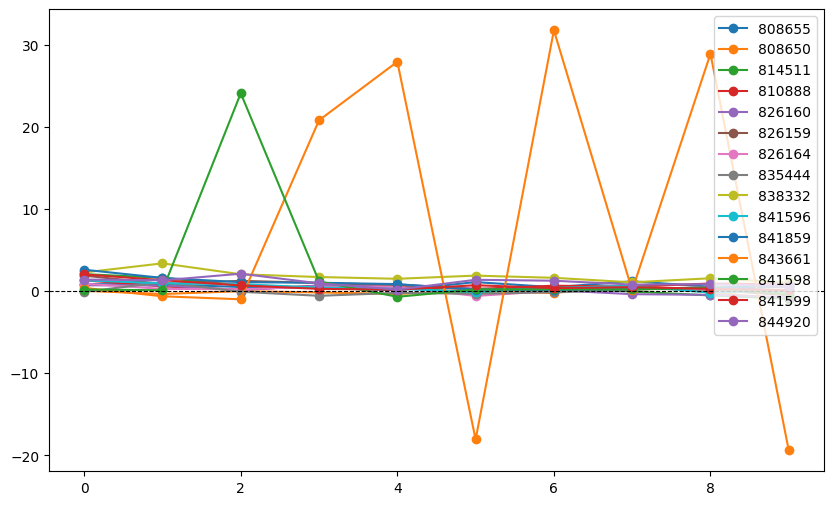

In [7]:
# plot the coefficients and CI
fig, ax = plt.subplots(figsize=(10, 6))
rwd_coeffs = all_results_df['rwd_coeffs'].values
rwd_CIs = all_results_df['rwd_CI'].values

for i in range(len(rwd_coeffs)):
    ax.plot(range(t_Max), rwd_coeffs[i], marker='o', label=f'{all_results_df["ani_id"].values[i]}')
    # ax.errorbar(range(3), rwd_coeffs[i], yerr=[rwd_coeffs[i] - rwd_CIs[i][:, 0], rwd_CIs[i][:, 1] - rwd_coeffs[i]], label='Reward Coefficients', alpha=0.7)
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.legend()

In [8]:
from joblib import Parallel, delayed
import numpy as np
import pandas as pd
import pickle
import statsmodels.api as sm


def _build_hit_glm_session_df(session, t_Max, t_Max_hist):
    session_tbl = get_session_tbl(session)

    hit = session_tbl['animal_response'].values != 2
    rewards = (
        (session_tbl['rewarded_historyL'].values == 1) |
        (session_tbl['rewarded_historyR'].values == 1)
    )

    choice = session_tbl['animal_response'].values
    # pre_choice = np.full(len(choice), np.nan)
    # pre_choice[1:] = choice[:-1]

    # for i in range(1, len(choice)):
    #     if pre_choice[i] == 2:  # no-go
    #         last_choice_inds = np.where(choice[:i] != 2)[0]
    #         last_choice = last_choice_inds[-1] if len(last_choice_inds) > 0 else -1
    #         pre_choice[i] = choice[last_choice] if last_choice >= 0 else np.nan

    hit_mtx = np.full((t_Max_hist, len(hit)), np.nan, dtype=float)
    for i in range(t_Max_hist):
        hit_mtx[i, i + 1:] = hit[:len(hit) - (i + 1)]

    rwd_mtx = np.full((t_Max, len(hit)), np.nan, dtype=float)
    for i in range(t_Max):
        rwd_mtx[i, i + 1:] = rewards[:len(hit) - (i + 1)]

    col_list = [f'rwd_{i+1}' for i in range(t_Max)]
    pre_hist_list = [f'hit_{i+1}' for i in range(t_Max_hist)]
    col_list.extend(pre_hist_list)

    matrix = np.concatenate((rwd_mtx, hit_mtx), axis=0)
    reg_df = pd.DataFrame(matrix.T, columns=col_list)
    reg_df['hit'] = hit
    # reg_df['pre_choice'] = pre_choice

    return reg_df


# regression model, use past rewards/no reward, to predict future go/no-go
def hit_glm_all_trial(t_Max, t_Max_hist=0, n_jobs=-1, backend='loky', verbose=10):
    session_list_file = '/root/capsule/scratch/results/manuscript/prep/combined_session_tbl/combined_beh_sessions.pkl'
    with open(session_list_file, 'rb') as f:
        combined_session_tbl = pickle.load(f)

    session_list = combined_session_tbl['session_id'].values

    reg_df_list = Parallel(n_jobs=n_jobs, backend=backend, verbose=verbose)(
        delayed(_build_hit_glm_session_df)(session, t_Max, t_Max_hist)
        for session in session_list
    )

    combined_reg_df = pd.concat(reg_df_list, ignore_index=True)

    X = combined_reg_df.drop(columns=['hit']).values
    y = combined_reg_df['hit'].values.astype(float)

    X = sm.add_constant(X)

    nan_mask = ~np.isnan(X).any(axis=1) & ~np.isnan(y)
    X = X[nan_mask]
    y = y[nan_mask]

    model = sm.Logit(y, X)
    result = model.fit()

    rwd_coeffs = result.params[1:t_Max + 1]
    hit_coeffs = result.params[t_Max + 1:t_Max + 1 + t_Max_hist]

    rwd_CI = result.conf_int()[1:t_Max + 1]
    hit_CI = result.conf_int()[t_Max + 1:t_Max + 1 + t_Max_hist]

    return {
        'rwd_coeffs': rwd_coeffs,
        'hit_coeffs': hit_coeffs,
        'rwd_CI': rwd_CI,
        'hit_CI': hit_CI,
        'model': result,
        'combined_reg_df': combined_reg_df,
    }

In [11]:
tMax = 15
tMax_hist = 15
result = hit_glm_all_trial(tMax, tMax_hist);

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    3.1s
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    5.5s
[Parallel(n_jobs=-1)]: Done  29 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done  40 out of  64 | elapsed:    8.9s remaining:    5.3s
[Parallel(n_jobs=-1)]: Done  47 out of  64 | elapsed:    9.8s remaining:    3.5s
[Parallel(n_jobs=-1)]: Done  54 out of  64 | elapsed:   11.7s remaining:    2.2s
[Parallel(n_jobs=-1)]: Done  61 out of  64 | elapsed:   12.4s remaining:    0.6s


Optimization terminated successfully.
         Current function value: 0.090330
         Iterations 9


[Parallel(n_jobs=-1)]: Done  64 out of  64 | elapsed:   14.3s finished


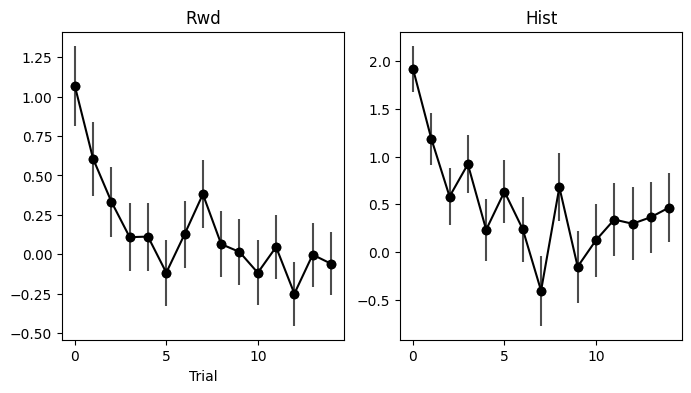

In [12]:
# plot results
rwd_coeffs = result['rwd_coeffs']
rwd_CI = result['rwd_CI']
hit_coeffs = result['hit_coeffs']
hit_CI = result['hit_CI']
fig, axes = plt.subplots(1, 2, figsize =(8, 4))
ax = axes[0]
ax.plot(range(tMax), rwd_coeffs, 'k', marker='o', label='Reward Coefficients')
ax.errorbar(range(tMax), rwd_coeffs, yerr=[rwd_coeffs - rwd_CI[:, 0], rwd_CI[:, 1] - rwd_coeffs], fmt='o', alpha=0.7, c = 'k')
ax.set_xlabel('Trial')
ax.set_title('Rwd')
ax = axes[1]
ax.plot(range(tMax_hist), hit_coeffs, 'k', marker='o', label='History Coefficients', )
ax.errorbar(range(tMax_hist), hit_coeffs, yerr=[hit_coeffs - hit_CI[:, 0], hit_CI[:, 1] - hit_coeffs], fmt='o', alpha=0.7, c = 'k')
ax.set_title('Hist')
save_dir = os.path.join(capsule_dirs["manuscript_fig_dir"], 'F_hit_miss')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'GLM_hit_reward_coefficients.pdf'), bbox_inches='tight')